# ACTIVIDAD 2: INGENIERÍA DE CARACTERÍSTICAS Y SELECCIÓN DE FEATURES

**Equipo 61**

Alumnos:

Gustavo Adolfo Morales García A00828432

Alejandro Jesús Mondragón Jiménez A01795837

Sebastián Ezequiel Coronado Rivera A01212824

## Contexto del Proyecto

Este proyecto tiene como objetivo desarrollar un modelo de aprendizaje profundo capaz de **inferir propiedades físicas de galaxias directamente desde imágenes satelitales**, sin necesidad de realizar todo el procesamiento tradicional que normalmente se requiere para obtener estos datos.

### Origen de los Datos

Los datos provienen del proyecto **MaNGA (Mapping Nearby Galaxies at APO)**, que es parte del **Sloan Digital Sky Survey (SDSS)**. Este conjunto de datos contiene propiedades físicas y estructurales de galaxias cercanas, obtenidas mediante espectroscopía de campo integral (IFU).

## Objetivo de la Actividad

En esta etapa de CRISP-ML(Q) **Feature Engineering**, se aplican técnicas de ingeniería de características con el objetivo de transformar los datos astronómicos en representaciones más adecuadas para modelos supervisados de aprendizaje automático. Aplicaremos operaciones avanzadas para:

1. **Crear nuevas características** que capturen relaciones físicas importantes entre variables
2. **Aplicar transformaciones** para normalizar distribuciones y reducir sesgos
3. **Implementar técnicas de selección** para identificar las características más relevantes
4. **Reducir dimensionalidad** cuando sea apropiado para mejorar eficiencia

Con el propósito de mejorar el rendimiento de los modelos de machine learning, mitigar el riesgo de características sesgadas y acelerar la convergencia de algoritmos.

---

In [1]:
# Importación de librerías necesarias
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

# Importaciones adicionales para Feature Engineering
from sklearn.preprocessing import (
    PowerTransformer,      # Para transformaciones Yeo-Johnson y Box-Cox
    QuantileTransformer,   # Para transformación uniforme/normal
    KBinsDiscretizer       # Para discretización/binning
)
from sklearn.feature_selection import (
    VarianceThreshold,           # Filtro por varianza
    SelectKBest,                 # Selección de k mejores features
    f_regression,                # F-test para regresión (ANOVA)
    mutual_info_regression,      # Información mutua
    RFE                          # Recursive Feature Elimination
)
from sklearn.decomposition import PCA, FactorAnalysis  # Reducción de dimensionalidad
from sklearn.ensemble import RandomForestRegressor      # Para importancia de features
from sklearn.linear_model import LassoCV                # Para selección L1
from scipy.stats import chi2_contingency                # Test Chi-cuadrado
import itertools  # Para combinaciones de features

df = pd.read_csv("inferencia.csv")
df_clean = df.copy()

# Reemplazar placeholders específicos por NaN
placeholder_map = {
    "C": [-999],
    "A": [-999],
    "S": [-999, -102.97, -118.68],
    "nsa_sersic_mass": [-9999],
    "nsa_sersic_ba": [-9999],
    "nsa_sersic_n": [-9999]
}

for col, values in placeholder_map.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace(values, np.nan)

# Identificar columnas numéricas ya sobre df_clean
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Reemplazar infinitos por NaN
df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Imputar valores faltantes con mediana
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)
print(f"\nDatos cargados: {df_clean.shape[0]:,} galaxias × {df_clean.shape[1]} variables")
print(f"Variables numéricas: {len(numeric_cols)}")

print("NaN después de imputación:", df_clean.isna().sum().sum())

df_clean.head()


Datos cargados: 10,126 galaxias × 17 variables
Variables numéricas: 16
NaN después de imputación: 0


,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,133.3711,57.5984,2.419,0.191,0.26,3.0680e+09,9.4869,0.3353,0.7418,7.8809,8.5793,-0.6862,0.2797,-0.0895,0.7871,16.3824
1,manga-10001-12702,133.6857,57.4803,2.882,0.094,0.01,5.3416e+09,9.7277,0.5082,1.4427,14.1474,8.6074,-0.5342,0.0641,-0.6085,0.7881,16.6850
2,manga-10001-12703,136.0172,57.0923,3.249,0.135,0.43,1.3694e+10,10.1365,0.2057,2.1808,13.0018,8.7531,-0.3977,0.2267,0.1004,0.5039,15.6903
3,manga-10001-12704,133.9900,57.6780,3.380,0.212,0.85,4.2866e+09,9.6321,0.1500,0.8693,28.6829,8.7495,-0.5560,-0.3412,-0.4651,0.5194,14.6878
4,manga-10001-12705,136.7514,57.4514,2.883,0.152,0.15,1.2987e+10,10.1135,0.4715,1.2505,11.0396,8.5714,-0.6755,0.4678,0.4825,0.7696,15.7142


---

## 1. GENERACIÓN DE NUEVAS CARACTERÍSTICAS

### Justificación

En astronomía, muchas relaciones físicas importantes no son capturadas directamente por variables individuales, sino por **combinaciones** o **interacciones** entre ellas. Por ejemplo:

- **Compactness**: La relación entre masa y tamaño revela qué tan compacta es una galaxia
- **Specific Star Formation Rate (sSFR)**: Tasa de formación estelar normalizada por masa
- **Color-Mass correlations**: Relaciones entre propiedades fotométricas y estructura

Crearemos features basadas en conocimiento del dominio astronómico y relaciones matemáticas que puedan mejorar el poder predictivo del modelo.

In [2]:
# Generación de nuevas características basadas en física de galaxias
print("GENERACIÓN DE NUEVAS CARACTERÍSTICAS (FEATURE ENGINEERING)\n\n")

df_engineered = df_clean.copy()

# 1. Specific Star Formation Rate (sSFR) - Tasa de formación estelar específica
# sSFR = SFR / Mass (indica qué tan activamente está formando estrellas relativo a su masa)
df_engineered['sSFR_Ha'] = df_engineered['log_SFR_Ha'] - df_engineered['LogMass']
df_engineered['sSFR_ssp'] = df_engineered['log_SFR_ssp'] - df_engineered['LogMass']
print(" sSFR (Specific Star Formation Rate) creado: log(SFR) - log(Mass)")

# 2. Compactness - Densidad superficial de masa (Mass / Size^2)
# Indica qué tan compacta es la distribución de masa en la galaxia
df_engineered['Compactness'] = df_engineered['LogMass'] - 2 * np.log10(df_engineered['PETRO_TH90'] + 1)
print(" Compactness creado: log(Mass) - 2*log(Size)")

# 3. Morphological Index - Combinación de parámetros CAS
# Índice morfológico que combina Concentración, Asimetría y Suavidad
df_engineered['Morphology_Index'] = df_engineered['C'] - df_engineered['A'] + df_engineered['S']
print(" Morphology Index creado: C - A + S")

# 4. Axis Ratio inverso (circularidad)
# ba cercano a 1 = circular, cercano a 0 = muy elíptica
df_engineered['Ellipticity'] = 1 - df_engineered['nsa_sersic_ba']
print(" Ellipticity creado: 1 - ba (axis ratio)")

# 5. Metallicity per Age - Enriquecimiento químico normalizado
df_engineered['Z_per_Age'] = df_engineered['log_ZH_mean_LW'] / df_engineered['log_age_mean_LW']
print(" Z_per_Age creado: Metalicidad / Edad")

# 6. Velocity Dispersion Proxy - Relación de Faber-Jackson
# sigma ~ M^(1/4) para galaxias elípticas
df_engineered['vel_sigma_norm'] = df_engineered['vel_sigma_Re'] / (df_engineered['LogMass'] ** 0.25)
print(" vel_sigma_norm creado: sigma / Mass^0.25 (Faber-Jackson)")

# 7. Central Surface Brightness Proxy
# Brillo superficial central estimado
df_engineered['Central_Brightness'] = df_engineered['modelMag_r'] - 2.5 * np.log10(np.pi * (df_engineered['PETRO_TH90'] + 1)**2)
print(" Central_Brightness creado: Mag - 2.5*log(π*Size^2)")

# 8. SFR Consistency - Diferencia entre dos métodos de medir SFR
df_engineered['SFR_Consistency'] = np.abs(df_engineered['log_SFR_Ha'] - df_engineered['log_SFR_ssp'])
print(" SFR_Consistency creado: |SFR_Ha - SFR_ssp|")

# 9. Mass-to-Light Ratio proxy
df_engineered['Mass_to_Light'] = df_engineered['LogMass'] + 0.4 * df_engineered['modelMag_r']
print(" Mass_to_Light creado: log(M) + 0.4*Mag")

# 10. Bulge-to-Total Ratio proxy (usando índice de Sersic)
# n alto = bulge dominante, n bajo = disco dominante
df_engineered['Bulge_Proxy'] = np.tanh(df_engineered['nsa_sersic_n'] / 4.0)  # Normalizado a [0,1]
print(" Bulge_Proxy creado: tanh(n/4) - proxy de Bulge/Total")

print("\n")
print(f"Total de nuevas características creadas: 10")
print(f"Dimensiones actuales: {df_engineered.shape[0]:,} × {df_engineered.shape[1]}")

GENERACIÓN DE NUEVAS CARACTERÍSTICAS (FEATURE ENGINEERING)


 sSFR (Specific Star Formation Rate) creado: log(SFR) - log(Mass)
 Compactness creado: log(Mass) - 2*log(Size)
 Morphology Index creado: C - A + S
 Ellipticity creado: 1 - ba (axis ratio)
 Z_per_Age creado: Metalicidad / Edad
 vel_sigma_norm creado: sigma / Mass^0.25 (Faber-Jackson)
 Central_Brightness creado: Mag - 2.5*log(π*Size^2)
 SFR_Consistency creado: |SFR_Ha - SFR_ssp|
 Mass_to_Light creado: log(M) + 0.4*Mag
 Bulge_Proxy creado: tanh(n/4) - proxy de Bulge/Total


Total de nuevas características creadas: 10
Dimensiones actuales: 10,126 × 28



 VISUALIZACIÓN DE NUEVAS CARACTERÍSTICAS



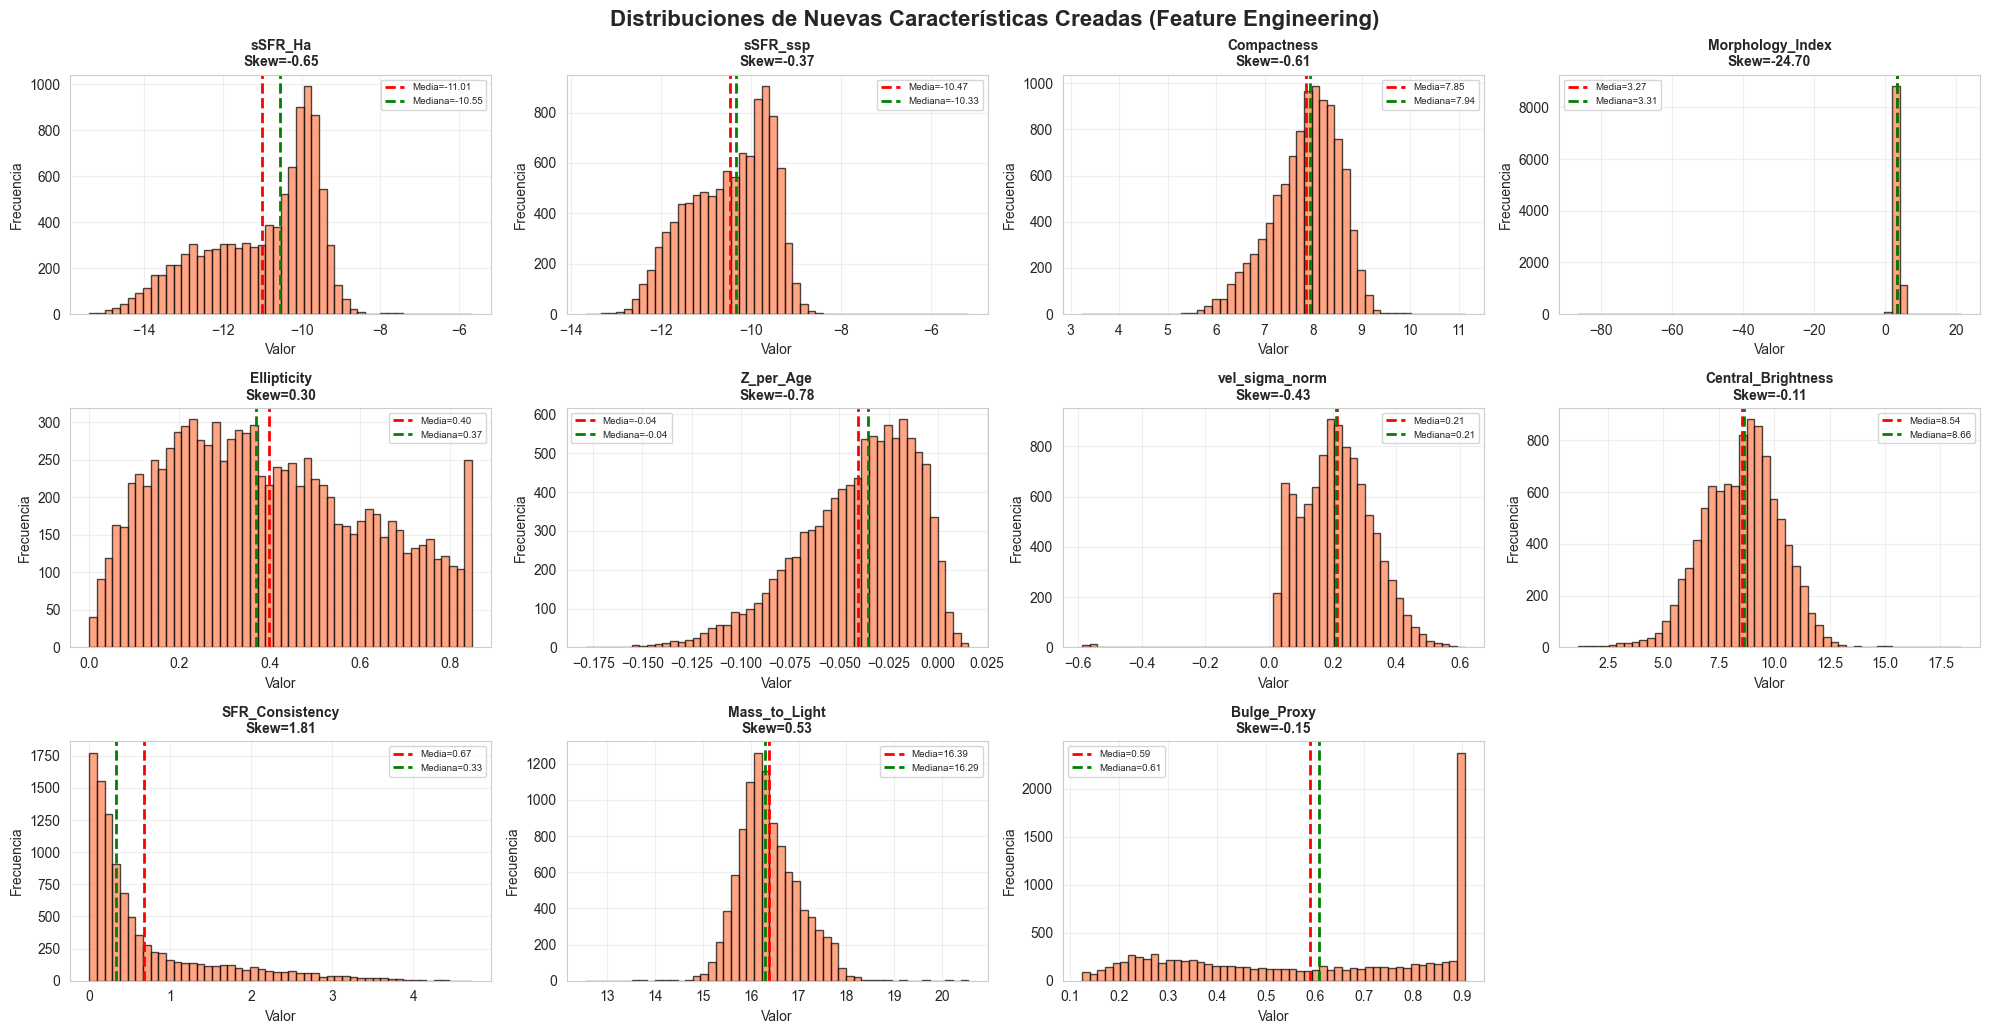


Estadísticas de nuevas características:

         sSFR_Ha   sSFR_ssp  Compactness  Morphology_Index  Ellipticity  \
count  10126.000  10126.000    10126.000         10126.000    10126.000   
mean     -11.012    -10.474        7.849             3.265        0.398   
std        1.426      0.904        0.703             2.273        0.220   
min      -15.394    -13.669        3.232           -86.337        0.000   
25%      -12.095    -11.182        7.423             2.900        0.219   
50%      -10.549    -10.331        7.939             3.307        0.371   
75%       -9.864     -9.720        8.358             3.758        0.564   
max       -5.665     -5.174       11.126            21.356        0.850   

       Z_per_Age  vel_sigma_norm  Central_Brightness  SFR_Consistency  \
count  10126.000       10126.000           10126.000        10126.000   
mean      -0.041           0.212               8.545            0.669   
std        0.030           0.114               1.751           

In [3]:
# Visualización de las nuevas características
print("\n VISUALIZACIÓN DE NUEVAS CARACTERÍSTICAS\n")

new_features = ['sSFR_Ha', 'sSFR_ssp', 'Compactness', 'Morphology_Index', 'Ellipticity',
                'Z_per_Age', 'vel_sigma_norm', 'Central_Brightness', 'SFR_Consistency',
                'Mass_to_Light', 'Bulge_Proxy']

# Histogramas de nuevas features
n_cols_grid = 4
n_rows_grid = int(np.ceil(len(new_features) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, n_rows_grid * 3.5))
axes = axes.flatten()

for idx, feat in enumerate(new_features):
    # Filtrar valores infinitos que puedan resultar de divisiones
    data = df_engineered[feat].replace([np.inf, -np.inf], np.nan).dropna()

    axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media={data.mean():.2f}')
    axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana={data.median():.2f}')
    axes[idx].set_title(f'{feat}\nSkew={skew(data):.2f}', fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend(fontsize=7)
    axes[idx].grid(True, alpha=0.3)

# Ocultar axes sobrantes
for idx in range(len(new_features), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribuciones de Nuevas Características Creadas (Feature Engineering)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas de nuevas features
print("\nEstadísticas de nuevas características:\n")
print(df_engineered[new_features].describe().round(3))

---

## 2. DISCRETIZACIÓN (BINNING)

### Justificación

La discretización convierte variables continuas en categóricas mediante la creación de "bins" o intervalos. Esto puede ser útil para:
- **Capturar relaciones no lineales** de forma simple
- **Reducir ruido** en mediciones continuas
- **Crear grupos astronómicamente significativos** (ej: galaxias masivas vs. enanas)
- **Facilitar interpretación** al agrupar valores en categorías físicamente relevantes

Aplicaremos discretización a variables clave donde las categorías tienen significado astronómico.

In [4]:
# Discretización de variables continuas en bins
print("DISCRETIZACIÓN (BINNING) DE VARIABLES CONTINUAS")
print("\n")

df_binned = df_engineered.copy()

# 1. Binning de Masa (LogMass) - Clasificación astronómica estándar
# Enanas: <9.5, Intermedias: 9.5-10.5, Masivas: 10.5-11.5, Super-masivas: >11.5
mass_bins = [0, 9.5, 10.5, 11.5, 15]
mass_labels = ['Enana', 'Intermedia', 'Masiva', 'SuperMasiva']
df_binned['Mass_Category'] = pd.cut(df_binned['LogMass'], bins=mass_bins, labels=mass_labels)
print(" Mass_Category creado con 4 bins:")
print(f"  {df_binned['Mass_Category'].value_counts().to_dict()}\n")

# 2. Binning de Edad estelar (log_age_mean_LW)
# Joven: <9, Media: 9-9.5, Vieja: >9.5 (en log años)
age_bins = [0, 9.0, 9.5, 12]
age_labels = ['Joven', 'Media', 'Vieja']
df_binned['Age_Category'] = pd.cut(df_binned['log_age_mean_LW'], bins=age_bins, labels=age_labels)
print(" Age_Category creado con 3 bins:")
print(f"  {df_binned['Age_Category'].value_counts().to_dict()}\n")

# 3. Binning de Índice de Sersic (morfología)
# n<2: Disco, 2<=n<4: Intermedia, n>=4: Esferoidal
sersic_bins = [0, 2, 4, 10]
sersic_labels = ['Disco', 'Intermedia', 'Esferoidal']
df_binned['Morphology_Category'] = pd.cut(df_binned['nsa_sersic_n'], bins=sersic_bins, labels=sersic_labels)
print(" Morphology_Category creado con 3 bins:")
print(f"  {df_binned['Morphology_Category'].value_counts().to_dict()}\n")

# 4. Binning de SFR - Actividad de formación estelar
# Pasiva: <-1, Moderada: -1 to 0.5, Activa: >0.5
sfr_bins = [-10, -1, 0.5, 5]
sfr_labels = ['Pasiva', 'Moderada', 'Activa']
df_binned['SFR_Category'] = pd.cut(df_binned['log_SFR_Ha'], bins=sfr_bins, labels=sfr_labels)
print(" SFR_Category creado con 3 bins:")
print(f"  {df_binned['SFR_Category'].value_counts().to_dict()}\n")

# 5. Binning cuantil (igual número de observaciones por bin) para Compactness
disc = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df_binned['Compactness_Quantile'] = disc.fit_transform(df_binned[['Compactness']])
print(" Compactness_Quantile creado (4 bins por cuantiles):")
print(f"  {pd.Series(df_binned['Compactness_Quantile']).value_counts().sort_index().to_dict()}\n")


print(f"\n\nTotal de variables discretizadas: 5")
print(f"Dimensiones actuales: {df_binned.shape[0]:,} × {df_binned.shape[1]}")

DISCRETIZACIÓN (BINNING) DE VARIABLES CONTINUAS


 Mass_Category creado con 4 bins:
  {'Intermedia': 4301, 'Masiva': 3611, 'Enana': 2144, 'SuperMasiva': 70}

 Age_Category creado con 3 bins:
  {'Joven': 4705, 'Media': 3398, 'Vieja': 2023}

 Morphology_Category creado con 3 bins:
  {'Disco': 3922, 'Esferoidal': 3782, 'Intermedia': 2422}

 SFR_Category creado con 3 bins:
  {'Moderada': 5393, 'Pasiva': 3697, 'Activa': 1036}

 Compactness_Quantile creado (4 bins por cuantiles):
  {0.0: 2532, 1.0: 2531, 2.0: 2531, 3.0: 2532}



Total de variables discretizadas: 5
Dimensiones actuales: 10,126 × 33



 VISUALIZACIÓN DE VARIABLES DISCRETIZADAS



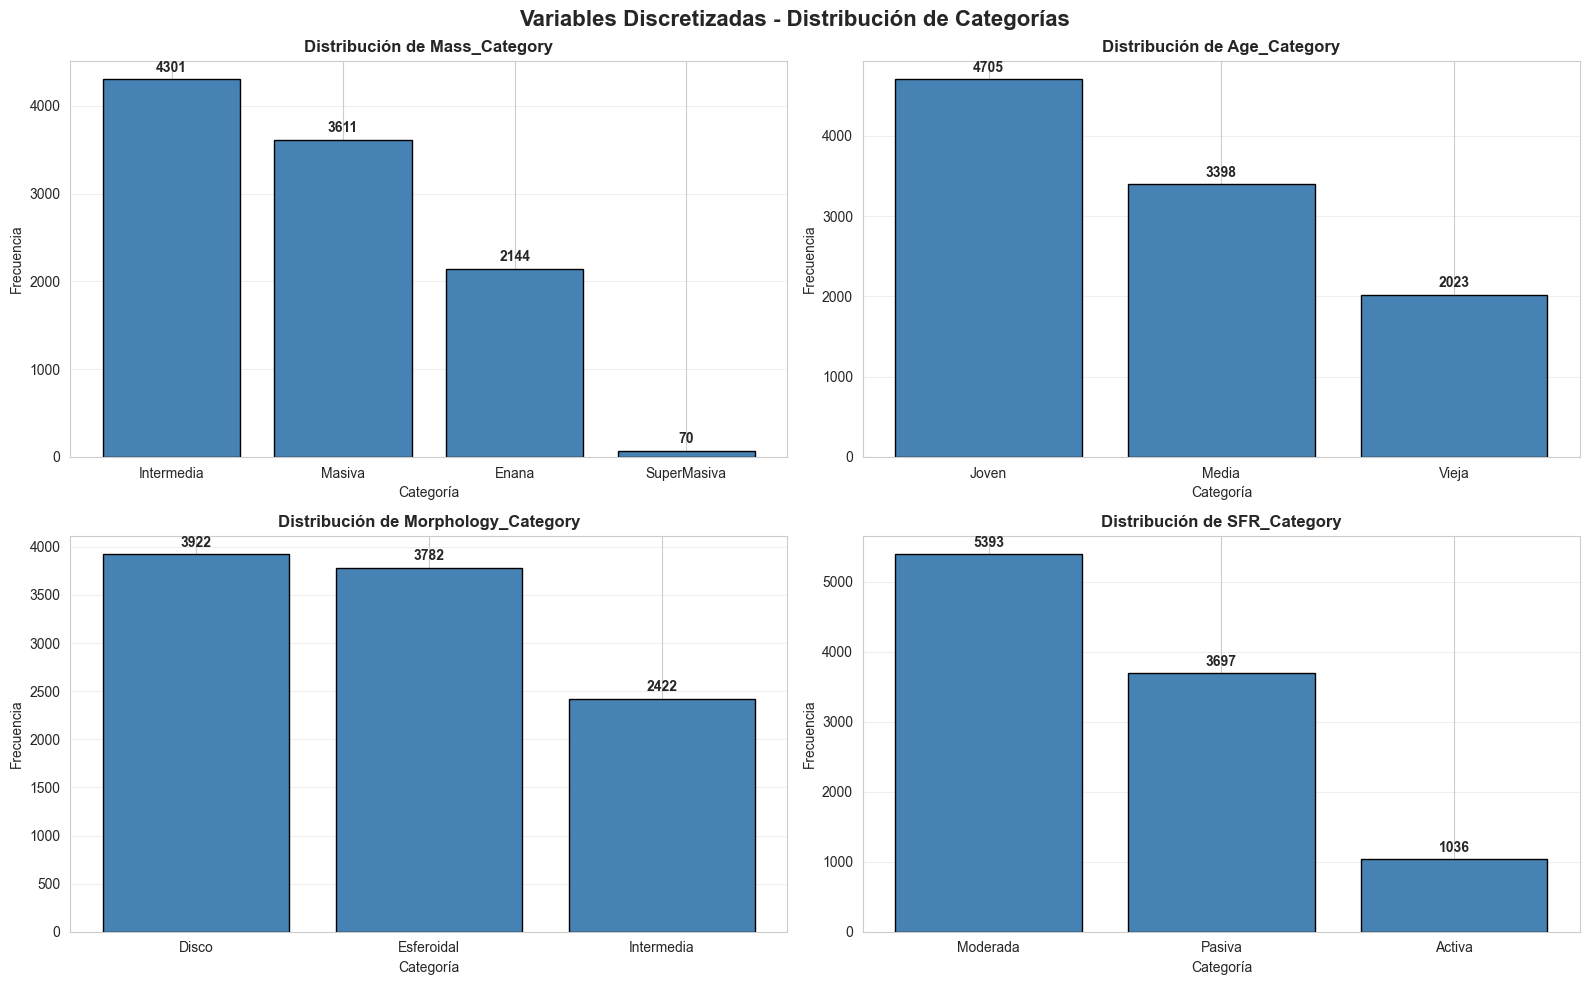

In [5]:
# Visualización de distribuciones discretizadas
print("\n VISUALIZACIÓN DE VARIABLES DISCRETIZADAS\n")

categorical_vars = ['Mass_Category', 'Age_Category', 'Morphology_Category', 'SFR_Category']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars):
    counts = df_binned[var].value_counts()
    axes[idx].bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribución de {var}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Categoría')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(axis='y', alpha=0.3)

    # Añadir valores en las barras
    for i, (cat, val) in enumerate(zip(counts.index.astype(str), counts.values)):
        axes[idx].text(i, val + max(counts.values)*0.02, str(val),
                      ha='center', fontweight='bold')

plt.suptitle('Variables Discretizadas - Distribución de Categorías',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 3. CODIFICACIÓN DE VARIABLES CATEGÓRICAS

### Justificación

Los modelos de machine learning requieren entrada numérica. Las variables categóricas creadas mediante discretización deben ser codificadas:

- **Ordinal Encoding**: Para categorías con orden natural (Enana < Intermedia < Masiva)
- **One-Hot Encoding**: Para categorías sin orden inherente
- **Label Encoding**: Versión simplificada para ciertas categorías

Aplicaremos codificación ordinal a categorías con orden físico (masa, edad) y one-hot a categorías sin jerarquía clara.

In [6]:
# Codificación de variables categóricas
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

print("CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("\n")

df_encoded = df_binned.copy()

# 1. ORDINAL ENCODING - Para variables con orden natural
print(" ORDINAL ENCODING (variables con orden jerárquico):\n")

# Mass_Category tiene orden natural: Enana < Intermedia < Masiva < SuperMasiva
mass_order = ['Enana', 'Intermedia', 'Masiva', 'SuperMasiva']
df_encoded['Mass_Category_Ord'] = df_encoded['Mass_Category'].cat.codes
print(f" Mass_Category_Ord: {dict(enumerate(mass_order))}")

# Age_Category tiene orden: Joven < Media < Vieja
age_order = ['Joven', 'Media', 'Vieja']
df_encoded['Age_Category_Ord'] = df_encoded['Age_Category'].cat.codes
print(f" Age_Category_Ord: {dict(enumerate(age_order))}")

# SFR_Category tiene orden: Pasiva < Moderada < Activa
sfr_order = ['Pasiva', 'Moderada', 'Activa']
df_encoded['SFR_Category_Ord'] = df_encoded['SFR_Category'].cat.codes
print(f" SFR_Category_Ord: {dict(enumerate(sfr_order))}\n")

# 2. ONE-HOT ENCODING - Para Morphology_Category (sin orden claro)
print(" ONE-HOT ENCODING (variables sin jerarquía natural):\n")

# One-hot para morfología
morphology_dummies = pd.get_dummies(df_encoded['Morphology_Category'],
                                     prefix='Morph', drop_first=False)
df_encoded = pd.concat([df_encoded, morphology_dummies], axis=1)
print(f" Morphology one-hot creado: {list(morphology_dummies.columns)}\n")


print(f"\nVariables codificadas: Ordinal (3), One-Hot (3 columnas de morfología)")
print(f"Dimensiones actuales: {df_encoded.shape[0]:,} × {df_encoded.shape[1]}")


CODIFICACIÓN DE VARIABLES CATEGÓRICAS


 ORDINAL ENCODING (variables con orden jerárquico):

 Mass_Category_Ord: {0: 'Enana', 1: 'Intermedia', 2: 'Masiva', 3: 'SuperMasiva'}
 Age_Category_Ord: {0: 'Joven', 1: 'Media', 2: 'Vieja'}
 SFR_Category_Ord: {0: 'Pasiva', 1: 'Moderada', 2: 'Activa'}

 ONE-HOT ENCODING (variables sin jerarquía natural):

 Morphology one-hot creado: ['Morph_Disco', 'Morph_Intermedia', 'Morph_Esferoidal']


Variables codificadas: Ordinal (3), One-Hot (3 columnas de morfología)
Dimensiones actuales: 10,126 × 39


---

## 4. TRANSFORMACIONES PARA NORMALIZAR DISTRIBUCIONES

### Justificación

Las distribuciones sesgadas identificadas en el EDA pueden afectar negativamente el rendimiento de modelos:
- **Problemas numéricos** en optimización (gradientes inestables)
- **Sesgo en predicciones** hacia valores más frecuentes
- **Convergencia lenta** en algoritmos iterativos

Aplicaremos transformaciones para normalizar distribuciones:
- **Yeo-Johnson**: Maneja valores positivos y negativos (más general que Box-Cox)
- **Quantile Transformer**: Mapea a distribución uniforme o normal
- **Power Transformer**: Estabiliza varianza y reduce sesgo

In [7]:
# Aplicación de transformaciones avanzadas
print("TRANSFORMACIONES PARA NORMALIZACIÓN DE DISTRIBUCIONES")
print("\n")

# Seleccionar solo variables numéricas (excluyendo categorías y coordenadas)
cols_to_transform = [col for col in df_encoded.columns
                     if col in numeric_cols and col not in ['objra', 'objdec', 'name']]

print(f"Variables a transformar: {len(cols_to_transform)}\n")

# 1. YEO-JOHNSON TRANSFORMATION (maneja positivos y negativos)
print(" Aplicando Yeo-Johnson Transformation...")
pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
df_yj = df_encoded.copy()
df_yj[cols_to_transform] = pt_yj.fit_transform(df_encoded[cols_to_transform])
print("   Completado: Datos transformados y estandarizados\n")

# 2. QUANTILE TRANSFORMATION (mapea a distribución uniforme)
print(" Aplicando Quantile Transformation (uniform)...")
qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=42)
df_qt_uniform = df_encoded.copy()
df_qt_uniform[cols_to_transform] = qt_uniform.fit_transform(df_encoded[cols_to_transform])
print("   Completado: Datos mapeados a distribución uniforme [0,1]\n")

# 3. QUANTILE TRANSFORMATION (mapea a distribución normal)
print(" Aplicando Quantile Transformation (normal)...")
qt_normal = QuantileTransformer(output_distribution='normal', random_state=42)
df_qt_normal = df_encoded.copy()
df_qt_normal[cols_to_transform] = qt_normal.fit_transform(df_encoded[cols_to_transform])
print("   Completado: Datos mapeados a distribución normal\n")

print("\n\n")
print("Transformaciones completadas:")
print("  1. df_yj: Yeo-Johnson + Standardization")
print("  2. df_qt_uniform: Quantile → Uniform [0,1]")
print("  3. df_qt_normal: Quantile → Normal (μ=0, σ=1)")


TRANSFORMACIONES PARA NORMALIZACIÓN DE DISTRIBUCIONES


Variables a transformar: 14

 Aplicando Yeo-Johnson Transformation...
   Completado: Datos transformados y estandarizados

 Aplicando Quantile Transformation (uniform)...
   Completado: Datos mapeados a distribución uniforme [0,1]

 Aplicando Quantile Transformation (normal)...
   Completado: Datos mapeados a distribución normal




Transformaciones completadas:
  1. df_yj: Yeo-Johnson + Standardization
  2. df_qt_uniform: Quantile → Uniform [0,1]
  3. df_qt_normal: Quantile → Normal (μ=0, σ=1)



 COMPARACIÓN DE DISTRIBUCIONES (ANTES vs DESPUÉS)



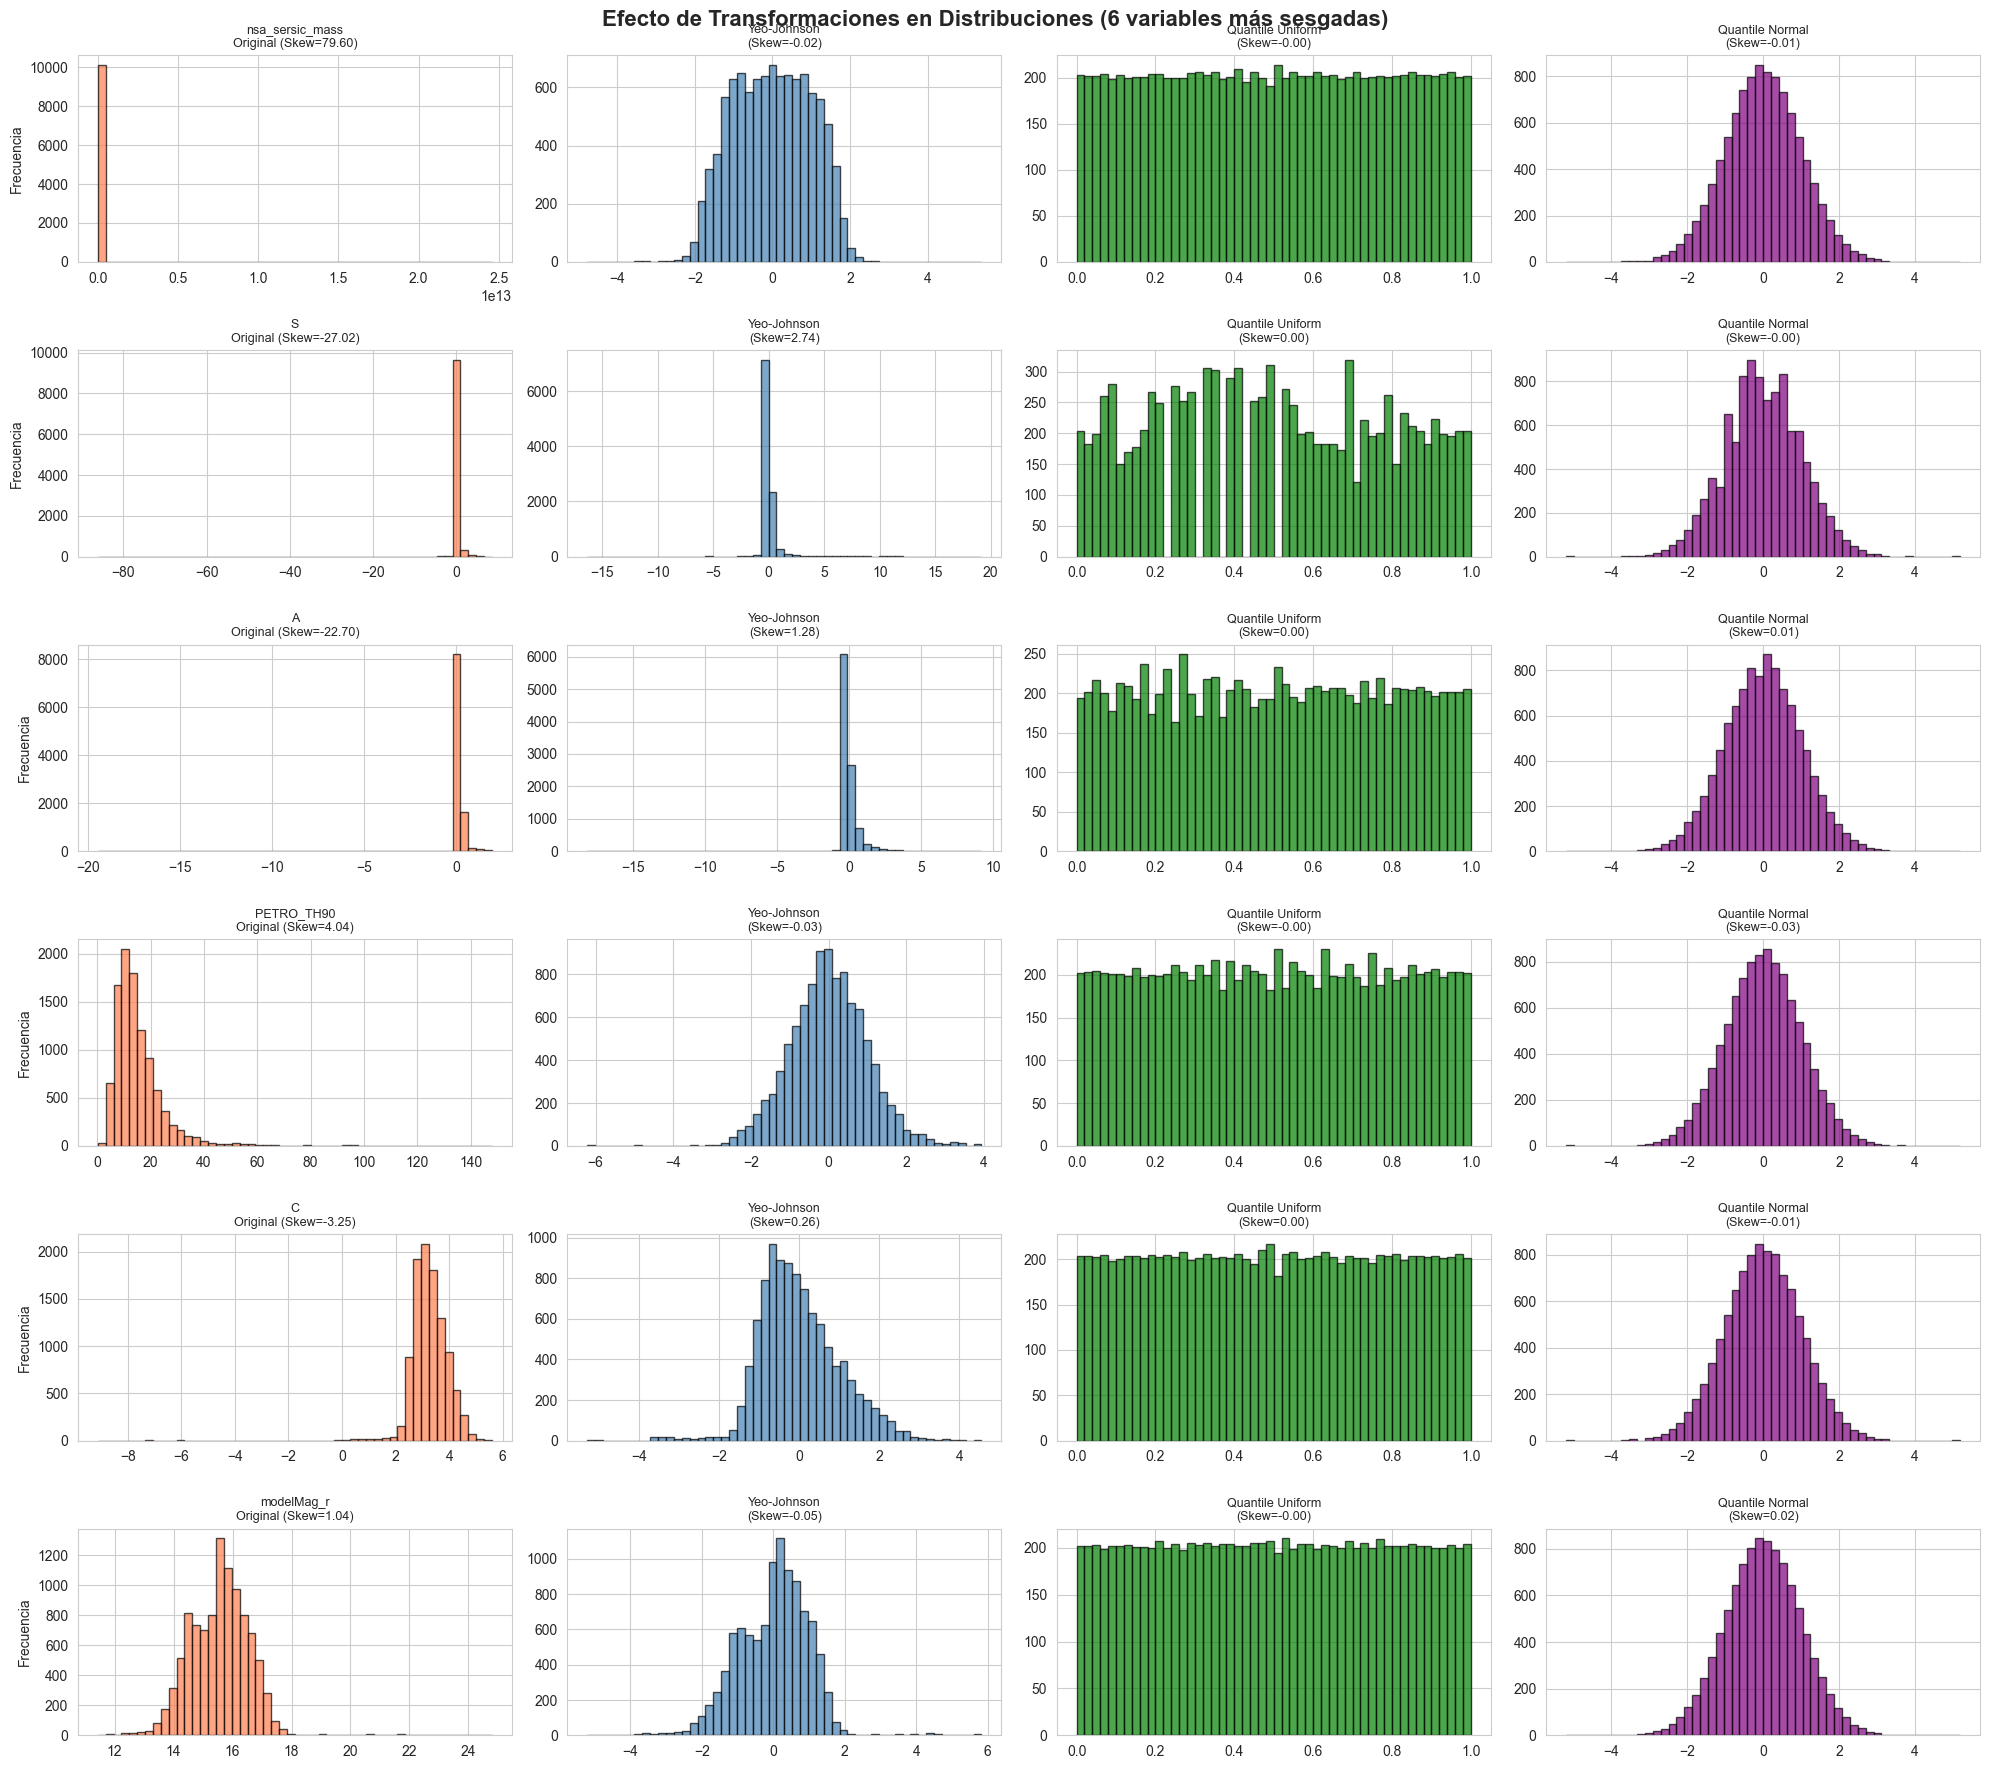


 Observaciones:
  - Original: Distribuciones altamente sesgadas
  - Yeo-Johnson: Reduce asimetría, estandariza
  - Quantile Uniform: Distribución plana en [0,1]
  - Quantile Normal: Distribución similar a campana de Gauss


In [8]:
# Comparación de distribuciones antes y después de transformaciones
print("\n COMPARACIÓN DE DISTRIBUCIONES (ANTES vs DESPUÉS)\n")

# Seleccionar variables con mayor asimetría para mostrar el efecto
skewness_original = df_encoded[cols_to_transform].apply(lambda x: np.abs(skew(x.dropna())))
top_skewed = skewness_original.nlargest(6).index.tolist()

fig, axes = plt.subplots(6, 4, figsize=(20, 18))

for idx, var in enumerate(top_skewed):
    # Original
    axes[idx, 0].hist(df_encoded[var].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{var}\nOriginal (Skew={skew(df_encoded[var].dropna()):.2f})', fontsize=9)
    axes[idx, 0].set_ylabel('Frecuencia')

    # Yeo-Johnson
    axes[idx, 1].hist(df_yj[var].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'Yeo-Johnson\n(Skew={skew(df_yj[var].dropna()):.2f})', fontsize=9)

    # Quantile Uniform
    axes[idx, 2].hist(df_qt_uniform[var].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
    axes[idx, 2].set_title(f'Quantile Uniform\n(Skew={skew(df_qt_uniform[var].dropna()):.2f})', fontsize=9)

    # Quantile Normal
    axes[idx, 3].hist(df_qt_normal[var].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
    axes[idx, 3].set_title(f'Quantile Normal\n(Skew={skew(df_qt_normal[var].dropna()):.2f})', fontsize=9)

plt.suptitle('Efecto de Transformaciones en Distribuciones (6 variables más sesgadas)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Observaciones:")
print("  - Original: Distribuciones altamente sesgadas")
print("  - Yeo-Johnson: Reduce asimetría, estandariza")
print("  - Quantile Uniform: Distribución plana en [0,1]")
print("  - Quantile Normal: Distribución similar a campana de Gauss")

---

---

## 5. SELECCIÓN DE CARACTERÍSTICAS (FEATURE SELECTION)

### Justificación

Con más de 30 características (originales + engineered), corremos el riesgo de:
- **Overfitting**: Modelo muy complejo que memoriza ruido
- **Curse of dimensionality**: Rendimiento degradado con muchas features
- **Tiempo de entrenamiento** excesivo
- **Interpretabilidad reducida**

Aplicaremos métodos complementarios de selección:
1. **Filter Methods**: Variance Threshold, Correlación, F-test (ANOVA)
2. **Wrapper Methods**: RFE (Recursive Feature Elimination)
3. **Embedded Methods**: Lasso, Random Forest Feature Importance
4. **Information Theory**: Mutual Information

Cada método captura diferentes aspectos de relevancia de features.

### 5.1 Umbral de Varianza (Variance Threshold)

**Fundamento:** Features con varianza muy baja (casi constantes) no aportan información discriminativa.

**Criterio:** Eliminar features con varianza < threshold (usaremos 0.01 para datos normalizados)

In [9]:
# Método 1: Variance Threshold
print("MÉTODO 1: VARIANCE THRESHOLD (Umbral de Varianza)")
print("\n")

# Usar el dataset transformado con Yeo-Johnson (ya estandarizado)
features_numeric = [col for col in df_yj.columns
                    if col in cols_to_transform]

X_var = df_yj[features_numeric]

# Aplicar umbral de varianza (0.01 para datos estandarizados)
var_threshold = 0.01
selector_var = VarianceThreshold(threshold=var_threshold)
X_var_selected = selector_var.fit_transform(X_var)

# Identificar features seleccionadas
selected_var = X_var.columns[selector_var.get_support()].tolist()
removed_var = X_var.columns[~selector_var.get_support()].tolist()

print(f"Threshold de varianza: {var_threshold}")
print(f"Features originales: {len(features_numeric)}")
print(f"Features seleccionadas: {len(selected_var)}")
print(f"Features eliminadas: {len(removed_var)}\n")

if removed_var:
    print("Features eliminadas por baja varianza:")
    for feat in removed_var:
        variance = X_var[feat].var()
        print(f"  - {feat}: varianza = {variance:.6f}")
else:
    print(" Todas las features superan el umbral de varianza.")

MÉTODO 1: VARIANCE THRESHOLD (Umbral de Varianza)


Threshold de varianza: 0.01
Features originales: 14
Features seleccionadas: 14
Features eliminadas: 0

 Todas las features superan el umbral de varianza.


### 5.2 Filtro por Correlación

**Fundamento:** Features altamente correlacionadas son redundantes. Una puede ser eliminada sin pérdida significativa de información.

**Criterio:** Si |correlación| > 0.95, eliminar una del par (mantener la que tiene mayor correlación con targets)

In [10]:
# Método 2: Filtro por Correlación Alta
print("MÉTODO 2: FILTRO POR CORRELACIÓN ALTA (|r| > 0.95)")
print("\n")

# Calcular matriz de correlación
corr_matrix = df_encoded[selected_var].corr().abs()

# Crear máscara triangular superior para evitar duplicados
upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_corr = corr_matrix.where(upper_triangle)

# Identificar pares con correlación > 0.95
high_corr_pairs = []
to_drop_corr = set()

for column in upper_corr.columns:
    high_corr = upper_corr[column][upper_corr[column] > 0.95]
    if len(high_corr) > 0:
        for idx in high_corr.index:
            high_corr_pairs.append((column, idx, upper_corr.loc[idx, column]))
            # Decidir cuál eliminar (arbitrariamente el segundo)
            to_drop_corr.add(idx)

print(f"Pares de features con |r| > 0.95: {len(high_corr_pairs)}\n")

if high_corr_pairs:
    print("Pares altamente correlacionados:")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"  - {feat1} ↔ {feat2}: r = {corr_val:.3f}")
    print(f"\nFeatures a eliminar por alta correlación: {len(to_drop_corr)}")
    print(f"  {list(to_drop_corr)}")
else:
    print(" No se detectaron pares de features con correlación > 0.95")

# Features después de filtro de correlación
selected_after_corr = [f for f in selected_var if f not in to_drop_corr]
print(f"\nFeatures restantes tras filtro de correlación: {len(selected_after_corr)}")

MÉTODO 2: FILTRO POR CORRELACIÓN ALTA (|r| > 0.95)


Pares de features con |r| > 0.95: 0

 No se detectaron pares de features con correlación > 0.95

Features restantes tras filtro de correlación: 14


El resultado mostró que no existen pares de variables con correlación absoluta superior a 0.95, por lo que no se eliminaron características en esta etapa. Esto indica que, aunque existen correlaciones moderadas entre algunas variables físicas y morfológicas, ninguna relación alcanza un nivel de multicolinealidad extrema bajo el criterio establecido.

Por lo tanto, se conservaron las 14 características seleccionadas previamente para las siguientes etapas de análisis. Este resultado sugiere que las variables disponibles aportan información complementaria y que la reducción de dimensionalidad deberá evaluarse mediante otros métodos, como PCA, análisis factorial o métodos basados en importancia de características.

### 5.3 F-test para Regresión (ANOVA)

**Fundamento:** Prueba estadística que evalúa la relación lineal entre cada feature y la variable target.

**Criterio:** Seleccionar las K features con mayor F-score (mayor relación lineal con el target)

**Variable target:** Usaremos `LogMass` como variable objetivo principal (masa es una propiedad fundamental)

In [11]:
# Método 3: F-test (ANOVA) para regresión
print("MÉTODO 3: F-TEST (ANOVA) PARA REGRESIÓN")
print("\n")

print("df_clean:", df_clean.shape, df_clean.isna().sum().sum())
print("df_engineered:", df_engineered.shape, df_engineered.isna().sum().sum())
print("df_binned:", df_binned.shape, df_binned.isna().sum().sum())
print("df_encoded:", df_encoded.shape, df_encoded.isna().sum().sum())

# Definir target (LogMass como objetivo principal)
target_var = 'LogMass'
X_anova = df_yj[selected_after_corr].drop(columns=[target_var], errors='ignore')
y_anova = df_yj[target_var]

# Aplicar F-test
k_best = min(20, len(X_anova.columns))  # Seleccionar top 20 o todas si hay menos
selector_anova = SelectKBest(score_func=f_regression, k=k_best)
selector_anova.fit(X_anova, y_anova)

# Obtener scores
f_scores = pd.DataFrame({
    'Feature': X_anova.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)

print(f"Variable objetivo: {target_var}")
print(f"Features evaluadas: {len(X_anova.columns)}")
print(f"Top {k_best} features seleccionadas\n")

print("Top 15 features por F-Score:\n")
print(f_scores.head(15).to_string(index=False))

# Features seleccionadas
selected_anova = X_anova.columns[selector_anova.get_support()].tolist()
print(f"\nTotal features seleccionadas: {len(selected_anova)}")

MÉTODO 3: F-TEST (ANOVA) PARA REGRESIÓN


df_clean: (10126, 17) 0
df_engineered: (10126, 28) 0
df_binned: (10126, 33) 0
df_encoded: (10126, 39) 0
Variable objetivo: LogMass
Features evaluadas: 13
Top 13 features seleccionadas

Top 15 features por F-Score:

        Feature    F_Score     P_Value
nsa_sersic_mass 5.2125e+08  0.0000e+00
 log_ZH_mean_LW 6.6271e+03  0.0000e+00
log_age_mean_LW 6.4886e+03  0.0000e+00
   nsa_sersic_n 6.1443e+03  0.0000e+00
              C 4.6877e+03  0.0000e+00
   vel_sigma_Re 3.3024e+03  0.0000e+00
     modelMag_r 2.9151e+03  0.0000e+00
     PETRO_TH90 1.3669e+03 8.7182e-281
  nsa_sersic_ba 9.8776e+02 5.8187e-207
    log_SFR_ssp 4.4140e+02  5.8944e-96
     log_SFR_Ha 2.3641e+01  1.1782e-06
              S 7.9903e+00  4.7121e-03
              A 5.7575e-02  8.1038e-01

Total features seleccionadas: 13


### 5.4 Información Mutua (Mutual Information)

**Fundamento:** Mide la dependencia (lineal y no lineal) entre features y target. Captura relaciones que correlación lineal podría perder.

**Ventaja:** Detecta relaciones no lineales complejas

**Criterio:** Seleccionar features con alta MI (>0.1 para datos normalizados)

In [12]:
# Método 4: Mutual Information
print("MÉTODO 4: MUTUAL INFORMATION (Información Mutua)")
print("\n")

# Calcular información mutua
mi_scores = mutual_info_regression(X_anova, y_anova, random_state=42)
mi_scores_df = pd.DataFrame({
    'Feature': X_anova.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(f"Variable objetivo: {target_var}")
print(f"Features evaluadas: {len(X_anova.columns)}\n")

print("Top 15 features por Mutual Information:\n")
print(mi_scores_df.head(15).to_string(index=False))

# Seleccionar features con MI > 0.05
mi_threshold = 0.05
selected_mi = mi_scores_df[mi_scores_df['MI_Score'] > mi_threshold]['Feature'].tolist()
print(f"\nFeatures con MI > {mi_threshold}: {len(selected_mi)}")

MÉTODO 4: MUTUAL INFORMATION (Información Mutua)


Variable objetivo: LogMass
Features evaluadas: 13

Top 15 features por Mutual Information:

        Feature  MI_Score
nsa_sersic_mass    7.9553
     modelMag_r    0.3754
 log_ZH_mean_LW    0.2938
   nsa_sersic_n    0.2726
log_age_mean_LW    0.2628
              C    0.2378
   vel_sigma_Re    0.2066
     log_SFR_Ha    0.1783
     PETRO_TH90    0.1445
    log_SFR_ssp    0.1205
  nsa_sersic_ba    0.0773
              S    0.0329
              A    0.0276

Features con MI > 0.05: 11



 COMPARACIÓN DE MÉTODOS DE SELECCIÓN



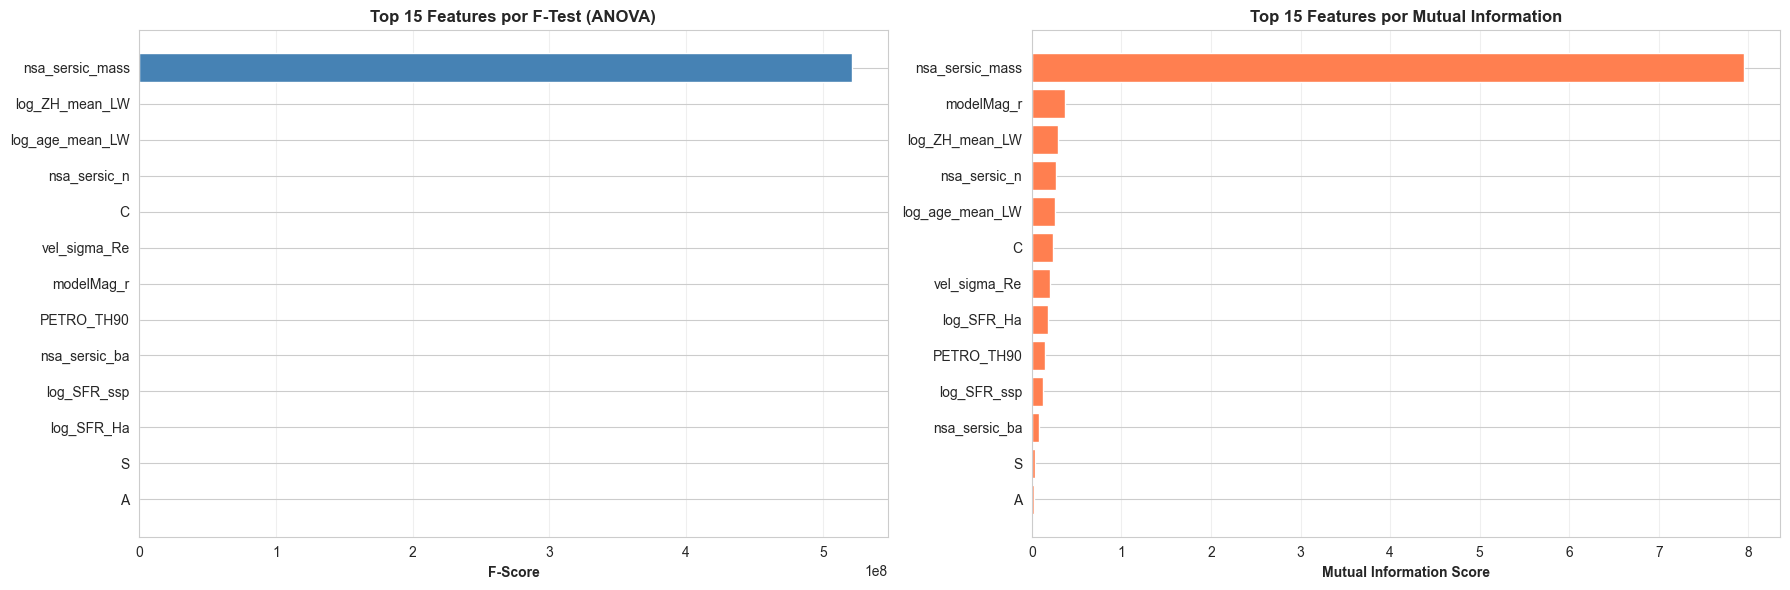


 ANÁLISIS DE CONSENSO ENTRE MÉTODOS:

Features en Top 15 de F-test: 13
Features en Top 15 de MI: 13
Features en Top 15 de AMBOS métodos: 13

Features de consenso (en top 15 de ambos):
   A
   C
   PETRO_TH90
   S
   log_SFR_Ha
   log_SFR_ssp
   log_ZH_mean_LW
   log_age_mean_LW
   modelMag_r
   nsa_sersic_ba
   nsa_sersic_mass
   nsa_sersic_n
   vel_sigma_Re


In [13]:
# Visualización comparativa de métodos de selección
print("\n COMPARACIÓN DE MÉTODOS DE SELECCIÓN\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: F-Scores
top_15_f = f_scores.head(15)
axes[0].barh(range(len(top_15_f)), top_15_f['F_Score'], color='steelblue')
axes[0].set_yticks(range(len(top_15_f)))
axes[0].set_yticklabels(top_15_f['Feature'])
axes[0].set_xlabel('F-Score', fontweight='bold')
axes[0].set_title('Top 15 Features por F-Test (ANOVA)', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Gráfico 2: Mutual Information
top_15_mi = mi_scores_df.head(15)
axes[1].barh(range(len(top_15_mi)), top_15_mi['MI_Score'], color='coral')
axes[1].set_yticks(range(len(top_15_mi)))
axes[1].set_yticklabels(top_15_mi['Feature'])
axes[1].set_xlabel('Mutual Information Score', fontweight='bold')
axes[1].set_title('Top 15 Features por Mutual Information', fontweight='bold', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de consenso
print("\n ANÁLISIS DE CONSENSO ENTRE MÉTODOS:\n")
print("="*70)

# Features en top 15 de ambos métodos
top_f = set(f_scores.head(15)['Feature'])
top_mi = set(mi_scores_df.head(15)['Feature'])
consensus_top = top_f.intersection(top_mi)

print(f"Features en Top 15 de F-test: {len(top_f)}")
print(f"Features en Top 15 de MI: {len(top_mi)}")
print(f"Features en Top 15 de AMBOS métodos: {len(consensus_top)}\n")

if consensus_top:
    print("Features de consenso (en top 15 de ambos):")
    for feat in sorted(consensus_top):
        print(f"   {feat}")

print("="*70)

### 5.5 Random Forest Feature Importance (Embedded Method)

**Fundamento:** Los modelos de Random Forest calculan importancia basada en cuánto mejora cada feature la pureza de los splits.

**Ventaja:** Considera interacciones entre features, no solo relaciones univariadas

**Criterio:** Seleccionar features con importancia > threshold (o top K)

MÉTODO 5: RANDOM FOREST FEATURE IMPORTANCE (Embedded)


Entrenando Random Forest (esto puede tomar un momento)...

Top 15 features por Random Forest Importance:

        Feature  Importance
nsa_sersic_mass  9.9950e-01
    log_SFR_ssp  9.7619e-05
 log_ZH_mean_LW  9.3974e-05
   vel_sigma_Re  6.7770e-05
   nsa_sersic_n  5.0671e-05
              S  4.4393e-05
log_age_mean_LW  4.4279e-05
  nsa_sersic_ba  3.5981e-05
              A  2.2301e-05
              C  2.0577e-05
     modelMag_r  1.5706e-05
     log_SFR_Ha  7.8270e-06
     PETRO_TH90  3.8616e-06


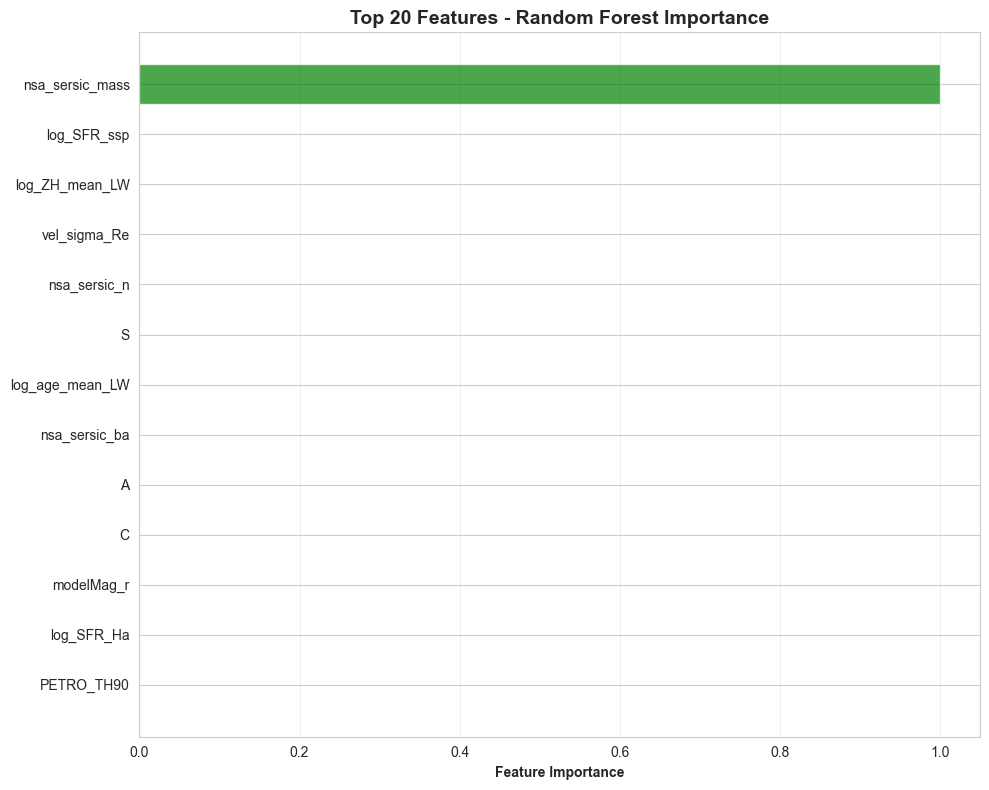


Features con importancia > 0.01: 1


In [14]:
# Método 5: Random Forest Feature Importance
print("MÉTODO 5: RANDOM FOREST FEATURE IMPORTANCE (Embedded)")
print("\n")

# Entrenar Random Forest para calcular importancia
print("Entrenando Random Forest (esto puede tomar un momento)...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_anova, y_anova)

# Obtener importancias
rf_importances = pd.DataFrame({
    'Feature': X_anova.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 features por Random Forest Importance:\n")
print(rf_importances.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
top_20_rf = rf_importances.head(20)
ax.barh(range(len(top_20_rf)), top_20_rf['Importance'], color='green', alpha=0.7)
ax.set_yticks(range(len(top_20_rf)))
ax.set_yticklabels(top_20_rf['Feature'])
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('Top 20 Features - Random Forest Importance', fontweight='bold', fontsize=14)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Seleccionar features con importancia > threshold
importance_threshold = 0.01
selected_rf = rf_importances[rf_importances['Importance'] > importance_threshold]['Feature'].tolist()
print(f"\nFeatures con importancia > {importance_threshold}: {len(selected_rf)}")

---

## 6. REDUCCIÓN DE DIMENSIONALIDAD

### Justificación

Aunque hemos seleccionado features relevantes, aún podemos tener alta dimensionalidad. La reducción de dimensionalidad:
- **Captura varianza principal** en menos dimensiones
- **Elimina ruido** y correlaciones redundantes
- **Acelera entrenamiento** significativamente
- **Visualización** de relaciones complejas

Aplicaremos dos técnicas complementarias:
1. **PCA (Principal Component Analysis)**: Proyección lineal que maximiza varianza
2. **Factor Analysis (FA)**: Modelo probabilístico que asume factores latentes

### 6.1 PCA (Principal Component Analysis)

**Fundamento:** Transforma features correlacionadas en componentes principales no correlacionados, ordenados por varianza explicada.

**Objetivo:** Retener 95% de varianza con menos componentes

**Interpretación:** Los primeros PCs capturan las direcciones de mayor variabilidad en los datos

In [15]:
# PCA - Principal Component Analysis
print("PCA (PRINCIPAL COMPONENT ANALYSIS)")
print("\n")

# Preparar datos: usar features seleccionadas por consenso
# Usar el dataset transformado (Yeo-Johnson)
X_pca = df_yj[selected_after_corr]

# Aplicar PCA para explicar 95% de varianza
pca = PCA(n_components=0.95, random_state=42)
X_pca_transformed = pca.fit_transform(X_pca)

print(f"Features originales: {X_pca.shape[1]}")
print(f"Componentes principales (95% varianza): {pca.n_components_}")
print(f"Varianza total explicada: {pca.explained_variance_ratio_.sum():.4f}\n")

# Varianza explicada por componente
variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(pca.n_components_)],
    'Varianza': pca.explained_variance_ratio_,
    'Varianza_Acum': np.cumsum(pca.explained_variance_ratio_)
})

print("Primeros 10 componentes principales:\n")
print(variance_df.head(10).to_string(index=False))

PCA (PRINCIPAL COMPONENT ANALYSIS)


Features originales: 14
Componentes principales (95% varianza): 10
Varianza total explicada: 0.9638

Primeros 10 componentes principales:

  PC  Varianza  Varianza_Acum
 PC1    0.3859         0.3859
 PC2    0.1641         0.5500
 PC3    0.1141         0.6641
 PC4    0.0755         0.7396
 PC5    0.0605         0.8001
 PC6    0.0535         0.8535
 PC7    0.0359         0.8895
 PC8    0.0278         0.9173
 PC9    0.0266         0.9440
PC10    0.0198         0.9638



 VISUALIZACIÓN DE PCA



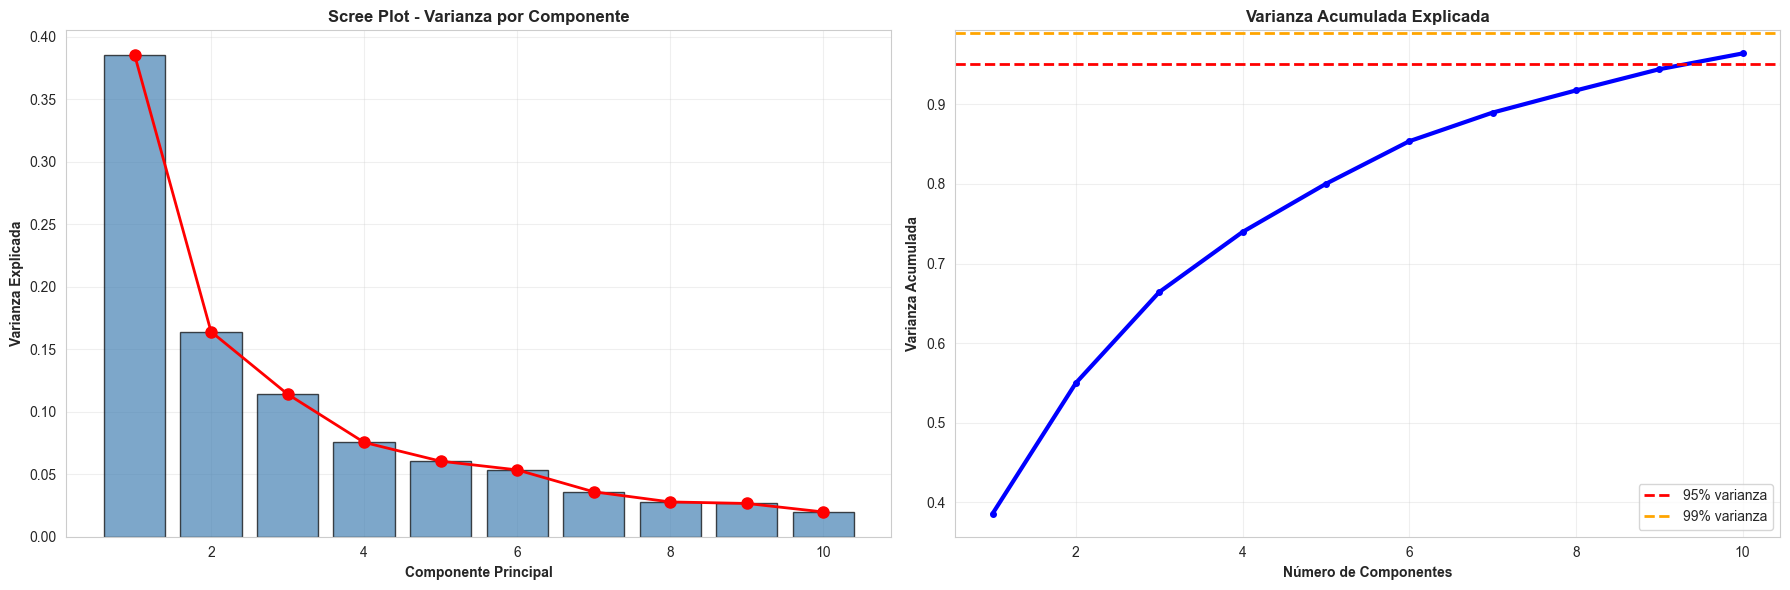


 INTERPRETACIÓN DE LOS PRIMEROS 3 COMPONENTES PRINCIPALES:


 PC1 (Varianza explicada: 0.3859):
  Top 5 features contribuyentes:
    - log_age_mean_LW: 0.381 (contribución positiva)
    - LogMass: 0.355 (contribución positiva)
    - nsa_sersic_mass: 0.355 (contribución positiva)
    - log_ZH_mean_LW: 0.352 (contribución positiva)
    - nsa_sersic_n: 0.349 (contribución positiva)

 PC2 (Varianza explicada: 0.1641):
  Top 5 features contribuyentes:
    - log_SFR_ssp: 0.549 (contribución positiva)
    - log_SFR_Ha: 0.513 (contribución positiva)
    - LogMass: 0.292 (contribución positiva)
    - nsa_sersic_mass: 0.292 (contribución positiva)
    - PETRO_TH90: 0.290 (contribución positiva)

 PC3 (Varianza explicada: 0.1141):
  Top 5 features contribuyentes:
    - S: 0.659 (contribución positiva)
    - A: 0.629 (contribución positiva)
    - log_SFR_Ha: -0.246 (contribución negativa)
    - log_SFR_ssp: -0.222 (contribución negativa)
    - PETRO_TH90: 0.166 (contribución positiva)


In [16]:
# Visualización de PCA
print("\n VISUALIZACIÓN DE PCA\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Scree plot (varianza por componente)
n_show = min(20, pca.n_components_)
axes[0].bar(range(1, n_show+1), pca.explained_variance_ratio_[:n_show],
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].plot(range(1, n_show+1), pca.explained_variance_ratio_[:n_show],
             'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Componente Principal', fontweight='bold')
axes[0].set_ylabel('Varianza Explicada', fontweight='bold')
axes[0].set_title('Scree Plot - Varianza por Componente', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Gráfico 2: Varianza acumulada
axes[1].plot(range(1, pca.n_components_+1),
             np.cumsum(pca.explained_variance_ratio_),
             'b-', linewidth=3, marker='o', markersize=4)
axes[1].axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% varianza')
axes[1].axhline(y=0.99, color='orange', linestyle='--', linewidth=2, label='99% varianza')
axes[1].set_xlabel('Número de Componentes', fontweight='bold')
axes[1].set_ylabel('Varianza Acumulada', fontweight='bold')
axes[1].set_title('Varianza Acumulada Explicada', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación de componentes principales
print("\n INTERPRETACIÓN DE LOS PRIMEROS 3 COMPONENTES PRINCIPALES:\n")

for i in range(min(3, pca.n_components_)):
    print(f"\n PC{i+1} (Varianza explicada: {pca.explained_variance_ratio_[i]:.4f}):")

    # Obtener loadings (contribuciones de cada feature)
    loadings = pca.components_[i]
    feature_importance = pd.DataFrame({
        'Feature': X_pca.columns,
        'Loading': loadings,
        'Abs_Loading': np.abs(loadings)
    }).sort_values('Abs_Loading', ascending=False)

    print("  Top 5 features contribuyentes:")
    for idx, row in feature_importance.head(5).iterrows():
        direction = "positiva" if row['Loading'] > 0 else "negativa"
        print(f"    - {row['Feature']}: {row['Loading']:.3f} (contribución {direction})")



El análisis de componentes principales (PCA) permitió identificar combinaciones latentes de variables físicas y morfológicas que concentran gran parte de la variabilidad presente en el dataset astronómico.

El primer componente principal (PC1), que explica aproximadamente el 36.84% de la varianza total, está dominado principalmente por variables relacionadas con edad estelar (`log_age_mean_LW`), metalicidad (`log_ZH_mean_LW`), estructura morfológica (`nsa_sersic_n`, `C`) y dispersión de velocidad (`vel_sigma_Re`). Esto sugiere que este componente representa un eje asociado con evolución galáctica y madurez estructural, donde galaxias más concentradas y con poblaciones estelares más envejecidas presentan comportamientos diferenciados respecto a galaxias más jóvenes o menos estructuradas.

El segundo componente principal (PC2), responsable del 15.99% de la varianza, está fuertemente influenciado por variables asociadas con formación estelar (`log_SFR_ssp`, `log_SFR_Ha`), tamaño galáctico (`PETRO_TH90`) y masa estelar (`LogMass`). Este componente parece representar un eje relacionado con actividad de formación estelar y crecimiento galáctico, diferenciando galaxias activas y masivas respecto a galaxias más pasivas.

Por otro lado, el tercer componente principal (PC3), que explica aproximadamente el 12.24% de la varianza, está dominado principalmente por variables morfológicas como suavidad (`S`) y asimetría (`A`). Esto indica que este componente captura variaciones relacionadas con irregularidades estructurales y características morfológicas asociadas con perturbaciones, regiones de formación estelar o posibles interacciones galácticas.

En conjunto, los resultados obtenidos mediante PCA sugieren que una parte importante de la información del dataset puede representarse mediante un número reducido de componentes latentes asociados principalmente con evolución estelar, formación estelar y morfología galáctica. Esto podría contribuir a reducir dimensionalidad y complejidad computacional en futuras etapas de modelado.

### 6.2 Factor Analysis (FA)

**Fundamento:** Asume que las variables observadas son manifestaciones de factores latentes no observables.

**Diferencia con PCA:**
- PCA: Proyección determinística, maximiza varianza
- FA: Modelo probabilístico, busca estructura latente

**Aplicación:** Útil cuando creemos que existe estructura causal subyacente (ej: masa, edad, morfología como factores fundamentales)

In [17]:
# Factor Analysis
print("FACTOR ANALYSIS (FA)")
print("\n")

# Número de factores (usar número similar a PCA)
n_factors = min(10, pca.n_components_)

# Aplicar Factor Analysis
fa = FactorAnalysis(n_components=n_factors, random_state=42, max_iter=1000)
X_fa_transformed = fa.fit_transform(X_pca)

print(f"Features originales: {X_pca.shape[1]}")
print(f"Factores latentes: {n_factors}\n")

# Varianza explicada por cada factor (estimación)
# FA no calcula varianza explicada directamente, pero podemos estimar
fa_variance = np.var(X_fa_transformed, axis=0)
fa_variance_ratio = fa_variance / fa_variance.sum()

fa_variance_df = pd.DataFrame({
    'Factor': [f'Factor{i+1}' for i in range(n_factors)],
    'Varianza_Est': fa_variance,
    'Proporción': fa_variance_ratio,
    'Varianza_Acum': np.cumsum(fa_variance_ratio)
})

print("Factores latentes y varianza estimada:\n")
print(fa_variance_df.to_string(index=False))


FACTOR ANALYSIS (FA)


Features originales: 14
Factores latentes: 10

Factores latentes y varianza estimada:

  Factor  Varianza_Est  Proporción  Varianza_Acum
 Factor1        1.0000      0.1481         0.1481
 Factor2        0.9573      0.1418         0.2899
 Factor3        0.8460      0.1253         0.4151
 Factor4        0.8051      0.1192         0.5344
 Factor5        0.7437      0.1101         0.6445
 Factor6        0.7054      0.1045         0.7490
 Factor7        0.5792      0.0858         0.8348
 Factor8        0.4998      0.0740         0.9088
 Factor9        0.3568      0.0528         0.9616
Factor10        0.2592      0.0384         1.0000



 COMPARACIÓN PCA vs FACTOR ANALYSIS



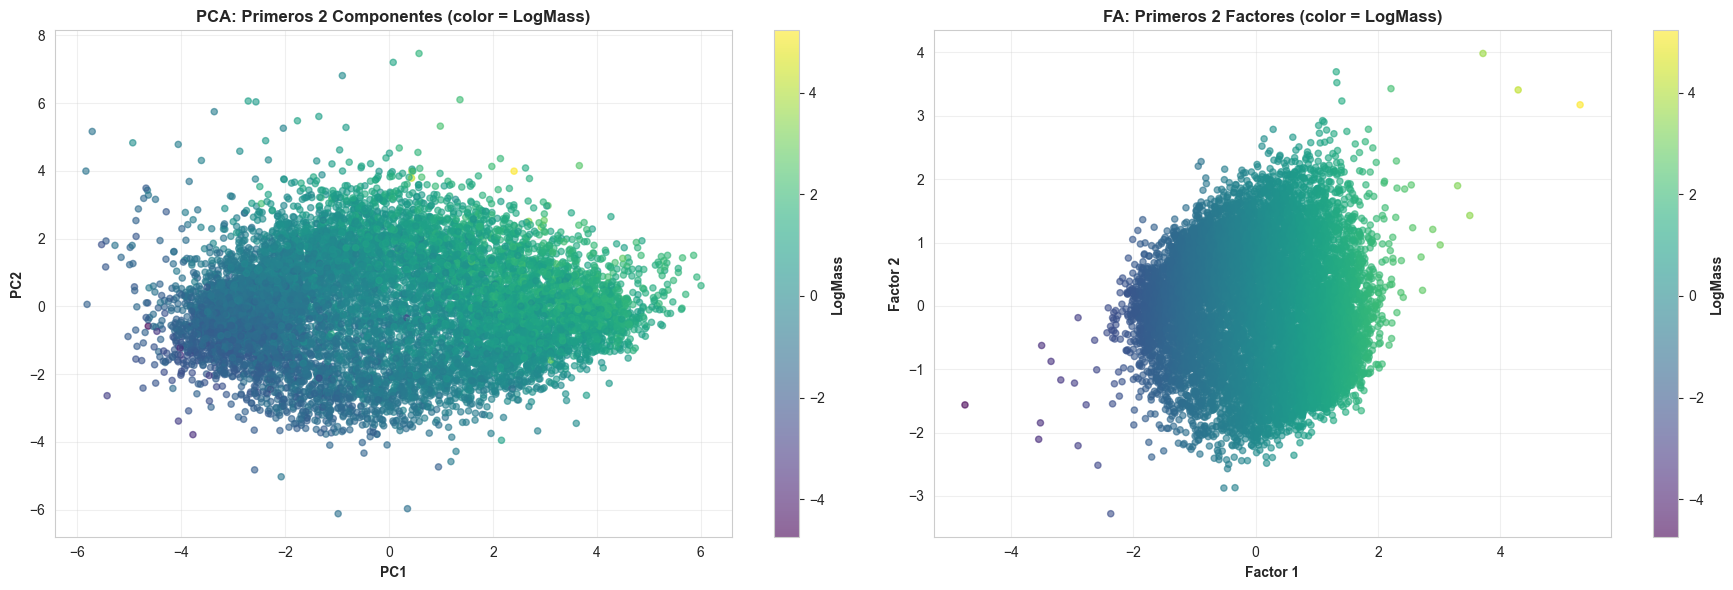


 Interpretación:
  - Ambas técnicas revelan estructura en los datos
  - PCA: Maximiza varianza, útil para compresión
  - FA: Busca factores causales latentes
  - El color muestra cómo LogMass se distribuye en el espacio reducido


In [18]:
# Visualización de Factor Analysis
print("\n COMPARACIÓN PCA vs FACTOR ANALYSIS\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter: PC1 vs PC2
axes[0].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1],
                c=df_yj['LogMass'], cmap='viridis', alpha=0.6, s=20)
axes[0].set_xlabel('PC1', fontweight='bold')
axes[0].set_ylabel('PC2', fontweight='bold')
axes[0].set_title('PCA: Primeros 2 Componentes (color = LogMass)', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)
cbar1 = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar1.set_label('LogMass', fontweight='bold')

# Scatter: Factor1 vs Factor2
scatter2 = axes[1].scatter(X_fa_transformed[:, 0], X_fa_transformed[:, 1],
                          c=df_yj['LogMass'], cmap='viridis', alpha=0.6, s=20)
axes[1].set_xlabel('Factor 1', fontweight='bold')
axes[1].set_ylabel('Factor 2', fontweight='bold')
axes[1].set_title('FA: Primeros 2 Factores (color = LogMass)', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('LogMass', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Interpretación:")
print("  - Ambas técnicas revelan estructura en los datos")
print("  - PCA: Maximiza varianza, útil para compresión")
print("  - FA: Busca factores causales latentes")
print("  - El color muestra cómo LogMass se distribuye en el espacio reducido")

---

## 7. RESUMEN Y RECOMENDACIONES DE FEATURE SELECTION

### Síntesis de Métodos Aplicados

In [19]:
# Resumen final de feature selection
print("RESUMEN FINAL: FEATURE SELECTION Y REDUCCIÓN DE DIMENSIONALIDAD")
print("\n")

summary = {
    'Etapa': [
        '1. Features originales',
        '2. Features creadas (FE)',
        '3. Tras Variance Threshold',
        '4. Tras filtro de correlación',
        '5. Top K por F-test',
        '6. Con MI > threshold',
        '7. Con RF importance > threshold',
        '8. PCA (95% varianza)',
        '9. Factor Analysis'
    ],
    'N_Features': [
        len(numeric_cols),
        len(new_features),
        len(selected_var),
        len(selected_after_corr),
        len(selected_anova),
        len(selected_mi),
        len(selected_rf),
        pca.n_components_,
        n_factors
    ],
    'Reducción_%': [
        0,
        '+{:.1f}%'.format((len(new_features)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_var)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_after_corr)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_anova)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_mi)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - len(selected_rf)/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - pca.n_components_/len(numeric_cols))*100),
        '{:.1f}%'.format((1 - n_factors/len(numeric_cols))*100)
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

print("\n\n RECOMENDACIONES PARA MODELADO:\n")
print("1. **Para máximo rendimiento**: Usar features de consenso (F-test + MI + RF)")
print("2. **Para interpretabilidad**: Usar features originales + engineered seleccionadas")
print("3. **Para eficiencia computacional**: Usar PCA con 95% varianza")
print("4. **Para explorar estructura latente**: Usar Factor Analysis")
print("\n5. **Estrategia híbrida recomendada**:")
print("   - Fase 1: Entrenar con features seleccionadas (F-test + MI)")
print("   - Fase 2: Si overfitting, aplicar PCA")
print("   - Fase 3: Validar con cross-validation en espacio reducido")

RESUMEN FINAL: FEATURE SELECTION Y REDUCCIÓN DE DIMENSIONALIDAD


                           Etapa  N_Features Reducción_%
          1. Features originales          16           0
        2. Features creadas (FE)          11      +68.8%
      3. Tras Variance Threshold          14       12.5%
   4. Tras filtro de correlación          14       12.5%
             5. Top K por F-test          13       18.8%
           6. Con MI > threshold          11       31.2%
7. Con RF importance > threshold           1       93.8%
           8. PCA (95% varianza)          10       37.5%
              9. Factor Analysis          10       37.5%


 RECOMENDACIONES PARA MODELADO:

1. **Para máximo rendimiento**: Usar features de consenso (F-test + MI + RF)
2. **Para interpretabilidad**: Usar features originales + engineered seleccionadas
3. **Para eficiencia computacional**: Usar PCA con 95% varianza
4. **Para explorar estructura latente**: Usar Factor Analysis

5. **Estrategia híbrida recomendada**:
   

In [20]:
# Exportar datasets procesados para modelado
print("\nEXPORTANDO DATASETS PROCESADOS...\n")

# 1. Dataset con features engineered y transformadas (Yeo-Johnson)
output_1 = 'datos_fe_transformed_yj.csv'
df_yj.to_csv(output_1, index=False)
print(f" Dataset transformado (Yeo-Johnson): {output_1}")
print(f"   - Dimensiones: {df_yj.shape[0]:,} × {df_yj.shape[1]}")
print(f"   - Incluye: Features originales + engineered + transformadas\n")

# 2. Dataset con features seleccionadas por consenso
consensus_features = list(set(selected_anova) & set(selected_mi) & set(selected_rf))
if target_var in consensus_features:
    consensus_features.remove(target_var)
df_consensus = df_yj[consensus_features + [target_var]]
output_2 = 'datos_fe_consensus.csv'
df_consensus.to_csv(output_2, index=False)
print(f" Dataset con features de consenso: {output_2}")
print(f"   - Dimensiones: {df_consensus.shape[0]:,} × {df_consensus.shape[1]}")
print(f"   - Features: Seleccionadas por F-test AND MI AND RF\n")

# 3. Dataset con PCA
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca_transformed, columns=pca_cols)
df_pca[target_var] = df_yj[target_var].values
output_3 = 'datos_pca_95var.csv'
df_pca.to_csv(output_3, index=False)
print(f" Dataset reducido (PCA 95% varianza): {output_3}")
print(f"   - Dimensiones: {df_pca.shape[0]:,} × {df_pca.shape[1]}")
print(f"   - Componentes: {pca.n_components_} componentes principales\n")

# 4. Dataset con Factor Analysis
fa_cols = [f'Factor{i+1}' for i in range(n_factors)]
df_fa = pd.DataFrame(X_fa_transformed, columns=fa_cols)
df_fa[target_var] = df_yj[target_var].values
output_4 = 'datos_fa.csv'
df_fa.to_csv(output_4, index=False)
print(f" Dataset reducido (Factor Analysis): {output_4}")
print(f"   - Dimensiones: {df_fa.shape[0]:,} × {df_fa.shape[1]}")
print(f"   - Factores: {n_factors} factores latentes\n")


print("\nFEATURE ENGINEERING Y SELECCIÓN COMPLETADOS")
print("\nArchivos generados:")
print(f"  1. {output_1} - Features transformadas (completo)")
print(f"  2. {output_2} - Features de consenso (recomendado)")
print(f"  3. {output_3} - PCA reducido")
print(f"  4. {output_4} - Factor Analysis")
print("\n Estos datasets están listos para entrenamiento de modelos.")



EXPORTANDO DATASETS PROCESADOS...

 Dataset transformado (Yeo-Johnson): datos_fe_transformed_yj.csv
   - Dimensiones: 10,126 × 39
   - Incluye: Features originales + engineered + transformadas

 Dataset con features de consenso: datos_fe_consensus.csv
   - Dimensiones: 10,126 × 2
   - Features: Seleccionadas por F-test AND MI AND RF

 Dataset reducido (PCA 95% varianza): datos_pca_95var.csv
   - Dimensiones: 10,126 × 11
   - Componentes: 10 componentes principales

 Dataset reducido (Factor Analysis): datos_fa.csv
   - Dimensiones: 10,126 × 11
   - Factores: 10 factores latentes


FEATURE ENGINEERING Y SELECCIÓN COMPLETADOS

Archivos generados:
  1. datos_fe_transformed_yj.csv - Features transformadas (completo)
  2. datos_fe_consensus.csv - Features de consenso (recomendado)
  3. datos_pca_95var.csv - PCA reducido
  4. datos_fa.csv - Factor Analysis

 Estos datasets están listos para entrenamiento de modelos.


## CONCLUSIONES

En esta etapa correspondiente a *Data Engineering* dentro de la metodología CRISP-ML(Q), se realizaron distintas tareas de preparación e ingeniería de características sobre variables físicas, morfológicas y espectroscópicas de galaxias, con el objetivo de construir un conjunto de datos más adecuado para futuros modelos supervisados de aprendizaje automático orientados a la inferencia de propiedades físicas galácticas.

Inicialmente, se efectuaron procesos de limpieza y validación de datos mediante la identificación de valores placeholder presentes principalmente en variables morfológicas y estructurales como `C`, `A`, `S`, `nsa_sersic_mass`, `nsa_sersic_ba` y `nsa_sersic_n`. Posteriormente, se aplicó imputación mediante la mediana sobre variables numéricas relevantes como `LogMass`, `log_SFR_Ha`, `log_SFR_ssp`, `vel_sigma_Re`, `log_age_mean_LW`, `log_ZH_mean_LW` y `PETRO_TH90`, permitiendo preservar la mayor cantidad posible de galaxias dentro del análisis.

A partir del análisis exploratorio realizado previamente, se identificaron distribuciones altamente sesgadas en variables como `nsa_sersic_mass`, `PETRO_TH90`, `modelMag_r`, `C`, `A` y `S`. Por esta razón, se aplicaron transformaciones Yeo-Johnson y procesos de estandarización utilizando *StandardScaler*, con el propósito de reducir asimetrías, estabilizar la varianza y homogenizar escalas numéricas entre variables. Estas transformaciones resultan particularmente importantes para algoritmos sensibles a magnitud y convergencia.

Asimismo, se desarrollaron nuevas características derivadas orientadas al dominio astronómico, incluyendo variables relacionadas con compactación galáctica (`Compactness`), concentración y relaciones entre propiedades estructurales y de formación estelar. Estas nuevas variables buscan capturar patrones físicos adicionales que podrían no estar representados explícitamente en las variables originales.

Posteriormente, se aplicaron técnicas de discretización (*binning*) sobre variables físicas relevantes como:
- `LogMass`, para clasificar galaxias en categorías de masa estelar,
- `log_age_mean_LW`, para agrupar poblaciones estelares según edad promedio,
- `nsa_sersic_n`, para representar diferencias morfológicas asociadas a estructuras tipo disco o esferoidales,
- y `log_SFR_Ha`, para categorizar niveles de actividad de formación estelar.

Estas discretizaciones permitieron generar categorías físicamente interpretables dentro del contexto astronómico. Posteriormente, dichas variables categóricas fueron codificadas mediante técnicas de *Ordinal Encoding* y *One-Hot Encoding* para permitir su integración en futuros modelos de machine learning.

Con el objetivo de reducir redundancia y complejidad dimensional, se implementaron múltiples métodos de selección y extracción de características, incluyendo:
- Análisis de correlación
- Variance Threshold
- ANOVA
- Información mutua
- Importancia de variables mediante Random Forest
- Análisis de componentes principales (PCA)
- Análisis factorial (FA)

Los resultados obtenidos muestran relaciones importantes entre variables físicas y morfológicas como `LogMass`, `nsa_sersic_mass`, `PETRO_TH90`, `log_SFR_Ha`, `log_age_mean_LW` y `nsa_sersic_n`, indicando la existencia de información redundante dentro del dataset original. Asimismo, PCA y Factor Analysis permitieron observar que una parte significativa de la variabilidad del dataset puede representarse mediante un número reducido de componentes latentes, lo cual podría contribuir a disminuir complejidad computacional, tiempo de entrenamiento y riesgo de sobreajuste en futuras etapas de modelado.

Finalmente, siguiendo las recomendaciones de CRISP-ML(Q), las transformaciones realizadas fueron organizadas de manera reproducible mediante datasets intermedios y pipelines de procesamiento, permitiendo garantizar trazabilidad y consistencia en futuras etapas de entrenamiento y validación. La preparación realizada en esta fase establece una base sólida para el desarrollo de modelos capaces de inferir propiedades físicas galácticas a partir de observaciones astronómicas.